# NY Yellow Taxi Analysis

For this excercise and for the purposes of delivering it in a timely manner, the scope of the dataset cleanup, EDA, and management summary of trends and recommendations is limited mostly to the variables of trip dates, total amount, duration, distance, and location.

## Index

1. [Load and overview](#load-and-overview) 
2. [Cleanup](#cleanup)
    - [Trip duration](#duration-of-trips)
    - [Trip distance](#distance-of-trip)
    - [Total trip amount](#total-amount-in-trips)
    - [Speed and variable interactions](#speed-variable-and-interaction-among-variables)
3. [EDA](#eda)
    - [Trip duration](#trip-duration)
    - [Trip distance](#trip-distance)
    - [Trip amount](#trip-amount)
4. [Management Summary]()


## Load and overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('Yellow_Taxi_Assignment.csv')

In [3]:
data.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2018-01-01 12:02:01,2018-01-01 12:04:05,1.0,0.53,1.0,N,142,163,1,3.5,0.0,0.5,1.29,0.0,0.3,5.59,NaN,NaN
1,2,2018-01-01 12:26:48,2018-01-01 12:31:29,1.0,1.05,1.0,N,140,236,1,6.0,0.0,0.5,1.02,0.0,0.3,7.82,NaN,NaN
2,2,2018-01-01 01:28:34,2018-01-01 01:39:38,4.0,1.83,1.0,N,211,158,1,9.5,0.5,0.5,1.62,0.0,0.3,12.42,NaN,NaN
3,1,2018-01-01 08:51:59,2018-01-01 09:01:45,1.0,2.30,1.0,N,249,4,2,10.0,0.0,0.5,0.00,0.0,0.3,10.80,NaN,NaN
4,2,2018-01-01 01:00:19,2018-01-01 01:14:16,1.0,3.06,1.0,N,186,142,1,12.5,0.5,0.5,1.00,0.0,0.3,14.80,NaN,NaN


In [4]:
# overview of shape, types of variables, and missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304978 entries, 0 to 304977
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               304978 non-null  int64  
 1   tpep_pickup_datetime   304978 non-null  object 
 2   tpep_dropoff_datetime  304978 non-null  object 
 3   passenger_count        295465 non-null  float64
 4   trip_distance          304978 non-null  float64
 5   RatecodeID             295465 non-null  float64
 6   store_and_fwd_flag     295465 non-null  object 
 7   PULocationID           304978 non-null  int64  
 8   DOLocationID           304978 non-null  int64  
 9   payment_type           304978 non-null  int64  
 10  fare_amount            304978 non-null  float64
 11  extra                  304978 non-null  float64
 12  mta_tax                304978 non-null  float64
 13  tip_amount             304978 non-null  float64
 14  tolls_amount           304978 non-nu

In [5]:
# check for duplicates

data.duplicated(keep='first').sum()

np.int64(0)

In [6]:
# dataset timespan
data.tpep_pickup_datetime.min(), data.tpep_pickup_datetime.max()


('2018-01-01 00:25:49', '2023-01-31 23:57:28')

ideas:

- year to year overview
- trends over the last five years
- seasonal trends

- hottest pick up spots
- most frequent routes
- hottest times of the days for trips


## Cleanup

In this section I create the variable trip duration and convert the variables of pickup and dropoff times to datetime variables for present and future time calculations.  

Then, I check for erroneous datapoints, and extreme/strange values in the total costs of trips, number of passengers, trip duration, and distance; and I drop the rows that correspond to extreme outliers or errors.

Before a detailed analysis of the most relevant numerical varaibles **I drop trips with 0 amount charged, 0 distance, and 0 length of time logged**.


In [7]:
# convert pickup and dropoff to datetime variables

data['conv_tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])
data['conv_tpep_dropoff_datetime'] = pd.to_datetime(data['tpep_dropoff_datetime'])

In [8]:
# create trip duration in minutes
data['conv_trip_duration'] = (data['conv_tpep_dropoff_datetime'].sub(data['conv_tpep_pickup_datetime'], axis = 0)).dt.total_seconds() / 60

In [9]:
# check for rows with 0 duration, amount, and distances
len(data[(data['trip_distance'] == 0) & (data['total_amount'] == 0)&(data['conv_trip_duration'] == 0)])

9

In [10]:
data.drop(data[(data['trip_distance'] == 0) & (data['total_amount'] == 0)&(data['conv_trip_duration'] == 0)].index, inplace=True)

In [11]:
len(data)

304969

### Duration of trips

I **dropped all trips lasting less than 1 minute** considering them as errors (the ones with negative duration at least) or voided trips. 

After an outlier analysis, I also **dropped all trips lasting more than 120 minutes**. The most extreme trips in this group lasted more than 20 hours, which I considered errors. For shorter trips, if I were to follow the ```3*IQR``` rule, the actual upper bound to consider an outlier is 52 minutes. However, this doesn't mean those datapoints are errors or should be dropped. 

A trip to a NYC airport from the city could potentially last as much as 90 minutes. This gives me some grounds to consider that long taxi trips might be infrequent but not errors. At the same time, long but realistic trips are a very small percentage of the dataset, so I kept some of them (between 52 and 120 minutes) and dropped the rest as a good trade off to remove some noise.

All in all, the dropped datapoints represent 1.26 % of the dataset. 

While I might decide to exclude very long or very short trips for the management summary if they skew means or bring too much noise in other ways, I do not think it's a good idea to drop them from the dataset altogether.



In [12]:
# for the cleanup, check the min and max trip durations to look for strange values
print(data['conv_trip_duration'].min())
print(data['conv_trip_duration'].max())

-44.13333333333333
1439.8666666666666


In [13]:
# sanity check for the con_trip_duration variable
data[data['conv_trip_duration']==-44.13333333333333]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,conv_tpep_pickup_datetime,conv_tpep_dropoff_datetime,conv_trip_duration
50712,1,2018-11-04 01:58:26,2018-11-04 01:14:18,2.0,2.4,1.0,N,246,148,1,...,0.5,3.3,0.0,0.3,16.6,NaN,NaN,2018-11-04 01:58:26,2018-11-04 01:14:18,-44.133333


In [14]:
# sanity check for the con_trip_duration variable
data[data['conv_trip_duration']==1439.8666666666666]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,conv_tpep_pickup_datetime,conv_tpep_dropoff_datetime,conv_trip_duration
127651,2,2020-02-16 23:27:01,2020-02-17 23:26:53,1.0,6.96,1.0,N,7,196,2,...,0.5,0.0,0.0,0.3,23.3,0.0,NaN,2020-02-16 23:27:01,2020-02-17 23:26:53,1439.866667


In [15]:
data.conv_trip_duration.mean()

np.float64(16.697668123645354)

/Users/victoriacolombo/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/victoriacolombo/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(-3.6805555555555554, 0.5, 'Count')

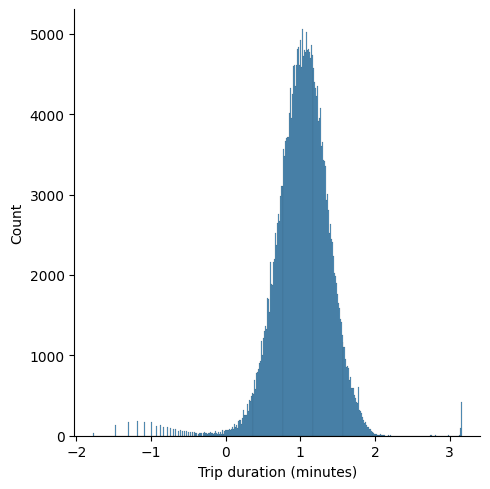

In [16]:
sns.displot(np.log10(data.conv_trip_duration), kde = False)
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Count")

In [17]:
# amount of trips that last less than a minute incl. negative duration
len(data[data['conv_trip_duration'] <=0])

391

In [18]:
# drop all trips with 0 or negative duration
data.drop(data[data['conv_trip_duration'] <= 0].index, inplace=True)

In [19]:
data['conv_trip_duration'].min()

np.float64(0.016666666666666666)

Text(-3.6805555555555554, 0.5, 'Count')

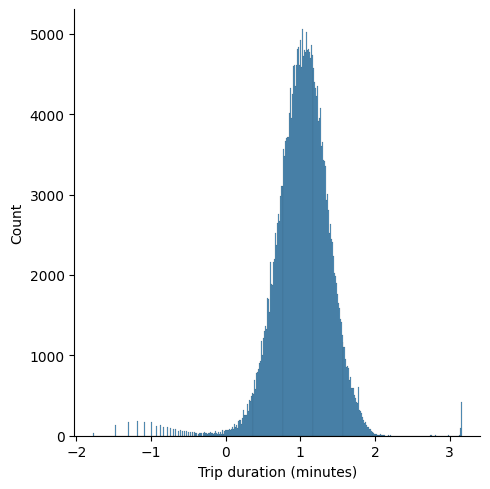

In [ ]:
sns.displot(np.log10(data.conv_trip_duration), kde = False)
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Count")
plt.title("Histogram of the trip duration")

In [21]:
# measure upper bound outliers with IQR method, set a manual lower bound of 1 minute 
iqr = data['conv_trip_duration'].quantile(0.75)-data['conv_trip_duration'].quantile(0.25)

lower_bound = 1
upper_bound = data['conv_trip_duration'].quantile(0.75) + 3 * iqr

outliers = data[
    (data['conv_trip_duration'] < lower_bound) |
    (data['conv_trip_duration'] > upper_bound)
]

outlier_proportion = len(outliers) / len(data)

print('IQR:', iqr, 'minutes')
print('Lower bound:', lower_bound)
print('Upper bound:', upper_bound)
print('Outliers:', len(outliers))
print('Percentage:', round((len(outliers) / len(data))*100,2), '%')

IQR: 11.45 minutes
Lower bound: 1
Upper bound: 52.41666666666666
Outliers: 8748
Percentage: 2.87 %


In [22]:
# datapoints included in more lenient upper bound and lower bound
ub = len(data[data['conv_trip_duration'] >120])
lb = len(data[data['conv_trip_duration'] <1])

In [23]:
print('Percentage of data to drop:', round(((ub+lb) / len(data))*100,2), '%')

Percentage of data to drop: 1.26 %


In [24]:
# new upper bound
lower_bound = 1
upper_bound = 120

outliers = data[
    (data['conv_trip_duration'] < lower_bound) |
    (data['conv_trip_duration'] > upper_bound)
]


In [25]:
data.drop(outliers.index, inplace=True)

Text(-3.6805555555555554, 0.5, 'Count')

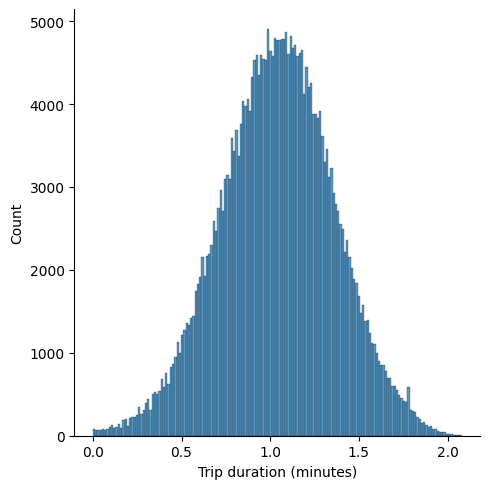

In [ ]:
sns.displot(np.log10(data.conv_trip_duration), kde = False)
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Count")
plt.title("Histogram of the trip duration")

### Distance of trip

I started by **dropping all trips with 0 miles logged and 0 amount charged**, and **all trips with 0 or negative mileage**.

After an outlier analysis I decided to **drop trips that were over 48 miles long**. This group includes very few trips that are very clearly errors in the data (trips of 10000 miles and over) and trips that might not represent errors (those lasting 50 miles, for example) but that are very few and might introduce a lot of noise later on. The 48 miles limit is based on the longest possible car journey in one direction one could make in NYC. On the lower bound, I **dropped trips lasting less than 0.3 miles** for similar reasons.

In total, 0.66% of the data was dropped in this sub section.

As with the previous cleanup, a lot more outliers appear using a ```3*IQR``` rule. Dropping those would mean dropping around 6% of the dataset. Later on, the reports can exclude or treat outliers for very long (48 miles) or very short (0.3 miles) differently. 

In [27]:
# trips with 0 distance

len(data[data['trip_distance'] == 0])

1785

In [28]:
len(data[(data['trip_distance'] == 0) & (data['total_amount'] == 0)])

14

In [29]:
data.drop(data[(data['trip_distance'] == 0) & (data['total_amount'] == 0)].index, inplace=True)

In [30]:
print(data.trip_distance.min())
print(data.trip_distance.max())

-16.86
177247.4


/Users/victoriacolombo/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/victoriacolombo/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(-3.6805555555555554, 0.5, 'Count')

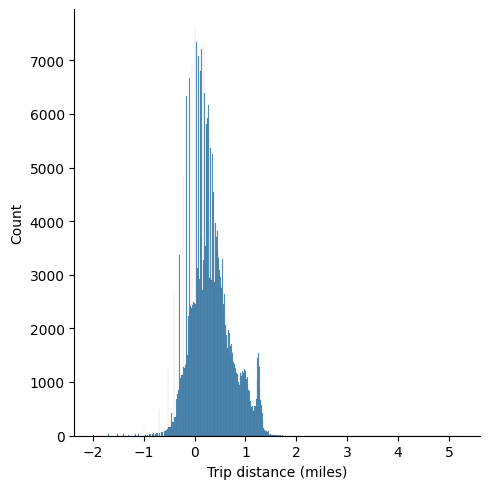

In [ ]:
sns.displot(np.log10(data.trip_distance), kde = False)
plt.xlabel("Trip distance (miles)")
plt.ylabel("Count")
plt.title("Histogram of the trip distance in miles")

In [32]:
len(data[data['trip_distance'] <= 0])

1780

In [33]:
# drop all trips with 0 or negative mileage
data.drop(data[data['trip_distance'] <= 0].index, inplace=True)

In [ ]:
# measure upper bound outliers with IQR method
iqr = data['trip_distance'].quantile(0.75)-data['trip_distance'].quantile(0.25)

lower_bound = data['trip_distance'].quantile(0.25) - 3 * iqr
upper_bound = data['trip_distance'].quantile(0.75) + 3 * iqr

outliers = data[
    (data['trip_distance'] < lower_bound) |
    (data['trip_distance'] > upper_bound)
]

outlier_proportion = len(outliers) / len(data)

print('IQR:', iqr, 'miles')
print('Lower bound:', lower_bound)
print('Upper bound:', upper_bound)
print('Outliers:', len(outliers))
print('Percentage:', round((len(outliers) / len(data))*100,2), '%')

IQR: 2.21 miles
Lower bound: -5.58
Upper bound: 9.89
Outliers: 20434
Percentage: 6.84 %


In [35]:
round(data.trip_distance.mean(),2)

np.float64(4.66)

In [36]:
len(data[data['trip_distance'] > 48])

32

In [37]:
(len(data[data['trip_distance'] > 48])/len(data))*100

0.010704704048385262

In [38]:
# datapoints included in more lenient upper bound and lower bound
ub = len(data[data['trip_distance'] >48])
lb = len(data[data['trip_distance'] <0.3])

In [39]:
print('Percentage of data to drop:', round(((ub+lb) / len(data))*100,2), '%')

Percentage of data to drop: 0.66 %


In [40]:
# new upper bound
lower_bound = 0.3
upper_bound = 48

outliers = data[
    (data['trip_distance'] < lower_bound) |
    (data['trip_distance'] > upper_bound)
]


In [41]:
data.drop(outliers.index, inplace=True)

Text(-3.6805555555555554, 0.5, 'Count')

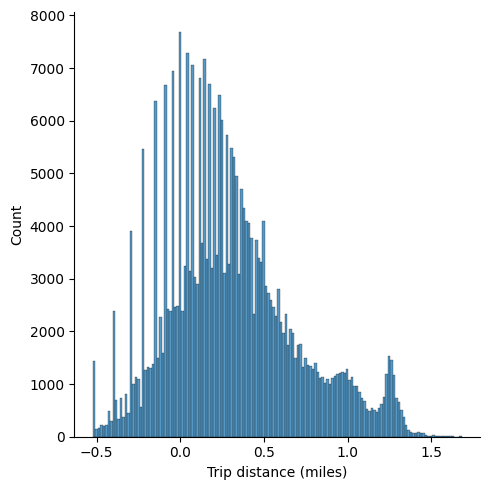

In [ ]:
sns.displot(np.log10(data.trip_distance), kde = False)
plt.xlabel("Trip distance (miles)")
plt.ylabel("Count")
plt.title("Histogram of the trip distance in miles")


### Total amount in trips

I started by **dropping all trips with a total amount of 0 or negative total amounts**, which are only 12 rows at this point. For all these rows, the distances and durations are non zero, which gives me grounds to believe they are errors. 

I also **dropped rows showing a high total amount but short durations** considering them as errors. This made up for around 0.02% of the dataset being dropped.

I decided not to go for a detailed analysis of the cost of trips and diffrent points of cutoff to eliminate further possible errors or noisy outliers because there aren't many and also trip costs can easily go up.

I do a deeper analysis of trips lengths and durations in the subsection of the speed variable to finally check data quality in a more holistic way.

In [ ]:
# trips with 0 amount

data[data['total_amount'] == 0]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,conv_tpep_pickup_datetime,conv_tpep_dropoff_datetime,conv_trip_duration
35879,2,2018-08-06 19:58:07,2018-08-06 20:02:10,1.0,1.03,1.0,N,7,7,2,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2018-08-06 19:58:07,2018-08-06 20:02:10,4.050000
58272,2,2018-12-19 20:36:00,2018-12-19 21:10:00,NaN,18.74,NaN,NaN,132,236,0,...,0.5,0.0,0.0,0.3,0.0,NaN,NaN,2018-12-19 20:36:00,2018-12-19 21:10:00,34.000000
76940,2,2019-04-12 00:33:07,2019-04-12 00:59:42,1.0,6.49,1.0,N,164,25,2,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2019-04-12 00:33:07,2019-04-12 00:59:42,26.583333
89071,2,2019-06-25 18:52:30,2019-06-25 18:59:41,1.0,1.32,1.0,N,140,263,2,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2019-06-25 18:52:30,2019-06-25 18:59:41,7.183333
109259,2,2019-10-27 01:30:42,2019-10-27 01:37:55,2.0,1.28,1.0,N,107,79,2,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2019-10-27 01:30:42,2019-10-27 01:37:55,7.216667
115327,2,2019-12-03 18:19:02,2019-12-03 18:54:49,1.0,8.37,1.0,N,13,262,2,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2019-12-03 18:19:02,2019-12-03 18:54:49,35.783333
118863,2,2019-12-22 00:23:00,2019-12-22 00:48:14,1.0,2.76,1.0,N,144,161,2,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2019-12-22 00:23:00,2019-12-22 00:48:14,25.233333
137671,2,2020-04-17 23:50:22,2020-04-18 00:36:02,1.0,16.74,1.0,N,138,20,2,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2020-04-17 23:50:22,2020-04-18 00:36:02,45.666667
152536,2,2020-07-17 20:39:32,2020-07-17 21:14:36,1.0,11.27,1.0,N,138,230,2,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2020-07-17 20:39:32,2020-07-17 21:14:36,35.066667
188161,2,2021-02-19 01:04:53,2021-02-19 01:22:02,2.0,7.50,1.0,N,48,116,2,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2021-02-19 01:04:53,2021-02-19 01:22:02,17.150000


In [83]:
data.drop(data[(data['total_amount'] <= 0)].index, inplace=True)

In [84]:
print(data.total_amount.min())
print(data.total_amount.max())

0.3
342.3


In [88]:
# sanity check for the max total amount value
pd.set_option('display.max_columns', None)

data[data['total_amount']==342.3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,conv_tpep_pickup_datetime,conv_tpep_dropoff_datetime,conv_trip_duration
55355,1,2018-12-03 20:22:52,2018-12-03 20:25:52,1.0,1.1,5.0,N,265,265,1,311.0,0.0,0.0,31.0,0.0,0.3,342.3,NaN,NaN,2018-12-03 20:22:52,2018-12-03 20:25:52,3.0


In [96]:
data.drop(data[(data['total_amount']==342.3)].index, inplace=True)

Text(0.5, 1.0, 'Histogram of the total trip amount in USD')

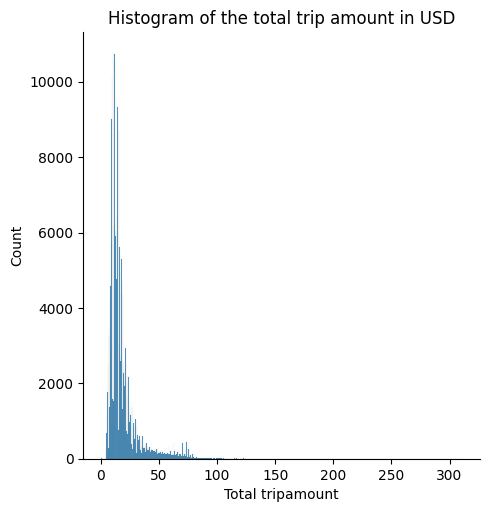

In [99]:
sns.displot(data.total_amount, kde = False)
plt.xlabel("Total tripamount")
plt.ylabel("Count")
plt.title("Histogram of the total trip amount in USD")

In [100]:
pd.set_option('display.max_columns', None)

data[data['total_amount']>100]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,conv_tpep_pickup_datetime,conv_tpep_dropoff_datetime,conv_trip_duration
792,2,2018-01-06 01:11:31,2018-01-06 01:46:07,1.0,25.68,5.0,N,132,265,1,99.0,0.00,0.0,23.11,16.26,0.3,138.67,NaN,NaN,2018-01-06 01:11:31,2018-01-06 01:46:07,34.600000
2128,2,2018-01-15 04:25:50,2018-01-15 04:47:46,1.0,17.31,3.0,N,164,1,1,64.0,0.50,0.0,16.76,19.00,0.3,100.56,NaN,NaN,2018-01-15 04:25:50,2018-01-15 04:47:46,21.933333
4409,1,2018-01-28 18:26:35,2018-01-28 19:01:52,1.0,20.00,3.0,N,163,1,1,72.0,0.00,0.0,16.95,12.50,0.3,101.75,NaN,NaN,2018-01-28 18:26:35,2018-01-28 19:01:52,35.283333
5642,2,2018-02-04 15:17:34,2018-02-04 15:49:17,2.0,17.61,5.0,N,164,1,1,76.0,0.00,0.5,28.47,18.10,0.3,123.37,NaN,NaN,2018-02-04 15:17:34,2018-02-04 15:49:17,31.716667
5800,2,2018-02-05 20:49:12,2018-02-05 21:26:15,1.0,23.30,5.0,N,231,265,1,80.0,0.00,0.5,18.26,10.50,0.3,109.56,NaN,NaN,2018-02-05 20:49:12,2018-02-05 21:26:15,37.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304708,1,2023-01-30 16:47:21,2023-01-30 17:36:11,1.0,19.60,2.0,N,132,141,1,70.0,8.75,0.5,17.35,6.55,1.0,104.15,2.5,1.25,2023-01-30 16:47:21,2023-01-30 17:36:11,48.833333
304731,2,2023-01-30 15:04:04,2023-01-30 15:54:56,1.0,21.18,2.0,N,132,209,1,70.0,0.00,0.5,20.14,6.55,1.0,101.94,2.5,1.25,2023-01-30 15:04:04,2023-01-30 15:54:56,50.866667
304754,2,2023-01-30 21:21:19,2023-01-30 21:49:51,2.0,18.34,2.0,N,132,230,1,70.0,0.00,0.5,24.16,6.55,1.0,105.96,2.5,1.25,2023-01-30 21:21:19,2023-01-30 21:49:51,28.533333
304824,2,2023-01-31 16:15:09,2023-01-31 16:53:21,1.0,16.23,2.0,N,132,233,1,70.0,5.00,0.5,17.11,6.55,1.0,103.91,2.5,1.25,2023-01-31 16:15:09,2023-01-31 16:53:21,38.200000


In [111]:
# measure upper bound outliers with IQR method
iqr = data['total_amount'].quantile(0.75)-data['total_amount'].quantile(0.25)

lower_bound = data['total_amount'].quantile(0.25) - 3 * iqr
upper_bound = data['total_amount'].quantile(0.75) + 3 * iqr

outliers = data[
    (data['total_amount'] < lower_bound) |
    (data['total_amount'] > upper_bound)
]

outlier_proportion = len(outliers) / len(data)

print('IQR:', iqr, 'USD')
print('Lower bound:', lower_bound)
print('Upper bound:', upper_bound)
print('Outliers:', len(outliers))
print('Percentage:', round((len(outliers) / len(data))*100,2), '%')

IQR: 9.760000000000002 USD
Lower bound: -18.280000000000005
Upper bound: 50.040000000000006
Outliers: 15518
Percentage: 5.24 %


In [ ]:
len(data[(data['total_amount'] >100) & (data['conv_trip_duration'] < 10)])

8

In [120]:
print('Percentage of data to drop:', (len(data[(data['total_amount'] >100) & (data['conv_trip_duration'] < 10)]) / len(data))*100, '%')

Percentage of data to drop: 0.0027011696064395884 %


In [121]:
data.drop(data[(data['total_amount'] >100) & (data['conv_trip_duration'] < 10)].index, inplace=True)

Text(0.5, 1.0, 'Histogram of the total trip amount in USD')

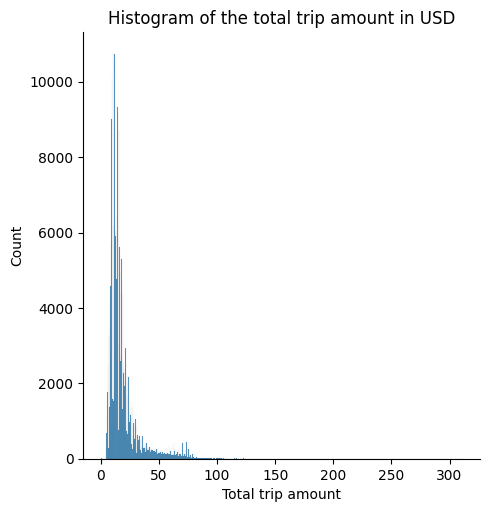

In [123]:
sns.displot(data.total_amount, kde = False)
plt.xlabel("Total trip amount")
plt.ylabel("Count")
plt.title("Histogram of the total trip amount in USD")


## Speed variable and interaction among variables

The last way to check for data quality in the main numeric variables is seeing their interactions. Are there long trips in time with 0 miles accounted for? What about expensive trips that are long in time but have no distance logged in?

As a way to look into this, I created the speed varaible to calculate the speed of the vehicles given the distance they travel and the time it takes them. Using this varaible, I dropped all rows with trips that seem to imply a vehicle moving above 70 miles per hour.



Note: Long trips with very few miles that have an accordingly high total amount are ok, they can be trips with a lot of traffic.

<Axes: xlabel='total_amount', ylabel='conv_trip_duration'>

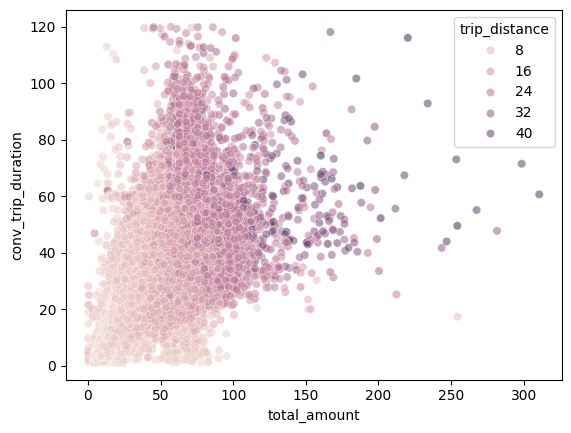

In [124]:
# trying to validate data quality by looking at the relationship between distance, duration, and total amount
sns.scatterplot(
    data=data,
    x='total_amount',
    y='conv_trip_duration',
    hue='trip_distance',
    alpha=0.5
)

In [107]:
data['speed_mph'] = (
    data['trip_distance'] /
    (data['conv_trip_duration'] / 60)
)

In [125]:
data.speed_mph.describe()

count    296160.000000
mean         12.170309
std           6.717222
min           0.279431
25%           7.977839
50%          10.588235
75%          14.392101
max         500.540541
Name: speed_mph, dtype: float64

In [134]:
(len(data[data['speed_mph'] > 70])/len(data))*100

0.0

In [133]:
data.drop(data[(data['speed_mph'] > 70)].index, inplace=True)

<Axes: xlabel='total_amount', ylabel='conv_trip_duration'>

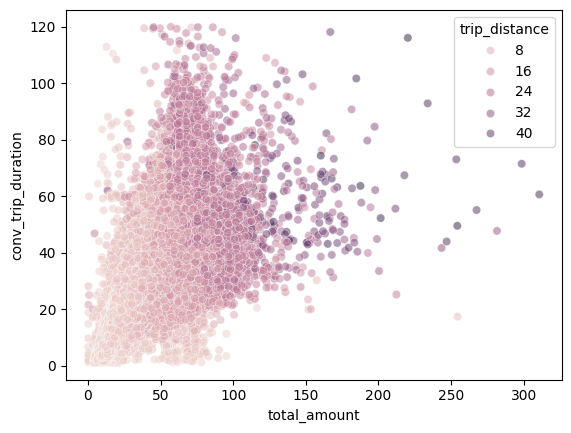

In [135]:
# trying to validate data quality by looking at the relationship between distance, duration, and total amount
sns.scatterplot(
    data=data,
    x='total_amount',
    y='conv_trip_duration',
    hue='trip_distance',
    alpha=0.5
)

## EDA

#### Trip duration
Trip duration is slightly right skewed with a median of 11.12 minutes and a mean of 14.3 minutes pulled upward by large outliers that lie within the top 7% of cases (roughly). 

The IQR is 11.3 minutes with the middle 50% of trips is between and 6 and 18 minutes. 

Around 90% of trips are shorter than 28 minutes, and only 1% of trips are longer than 1 hour.

In [89]:
print('Duration mean:',data.conv_trip_duration.mean(),'\n')
print('Duration median:',data.conv_trip_duration.median(),'\n')
print('Duration quantiles:\n',data.conv_trip_duration.quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99]),'\n')
print('Duration iqr:', data['conv_trip_duration'].quantile(0.75)-data['conv_trip_duration'].quantile(0.25))

Duration mean: 14.3593031343591 

Duration median: 11.166666666666666 

Duration quantiles:
 0.25     6.816667
0.50    11.166667
0.75    18.116667
0.90    28.000000
0.95    36.500000
0.99    59.166667
Name: conv_trip_duration, dtype: float64 

Duration iqr: 11.3


(0.0, 60.0)

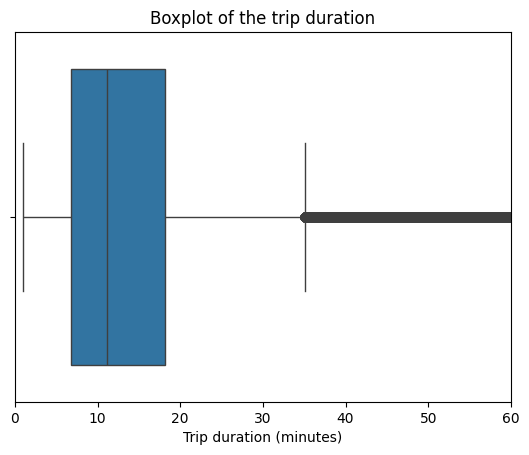

In [ ]:
sns.boxplot(x=data['conv_trip_duration'])
plt.title("Boxplot of the trip duration")
plt.xlabel("Trip duration (minutes)")

plt.xlim(0, 60)

#### Trip distance
Trip distance is right skewed with a median of 1.78 miles and a mean of 3.18 miles pulled upward by a few long-distance trips. 

The IQR is 2.23 miles with the middle 50% of trips is between 1.06 and 3.29 miles.

 Around 90% of trips are shorter than 7.5 miles, and only 1% of trips are 19 miles or longer.

In [75]:
print('Distance mean:',data.trip_distance.mean(),'\n')
print('Distance median:',data.trip_distance.median(),'\n')
print('Distance quantiles:\n',data.trip_distance.quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99]),'\n')
print('Distance iqr:', data['trip_distance'].quantile(0.75)-data['trip_distance'].quantile(0.25))

Distance mean: 3.1838535906951067 

Distance median: 1.78 

Distance quantiles:
 0.25     1.06
0.50     1.78
0.75     3.29
0.90     7.53
0.95    11.86
0.99    19.50
Name: trip_distance, dtype: float64 

Distance iqr: 2.23


(0.0, 20.0)

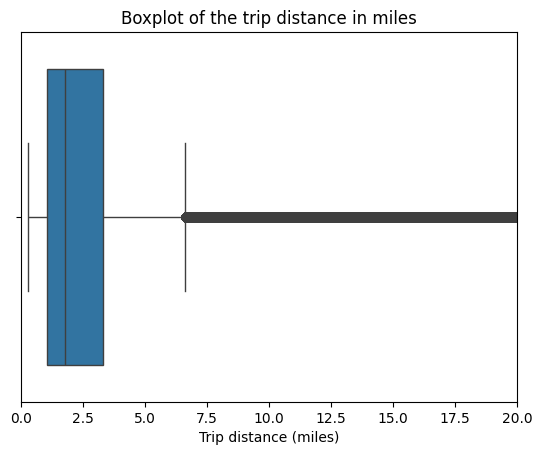

In [ ]:
sns.boxplot(x=data['trip_distance'])
plt.title("Boxplot of the trip distance")
plt.xlabel("Trip distance (miles)")

plt.xlim(0, 20)

#### Trip amount
The trip amount or total trip cost is strongly right skewed, with a median of $14.70 and a mean of $19.05 pulled upwards by a small number of expensive trips.

The IQR is $9.76, with the middle 50% of trips costing between $11.00 and $20.76.

Around 90% of trips cost less than $34.44, while only 1% exceed $75.72 (roughly).


In [138]:
print('Total amount mean:',data.total_amount.mean(),'\n')
print('Total amount median:',data.total_amount.median(),'\n')
print('Total amount quantiles:\n',data.total_amount.quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99]),'\n')
print('Total amount iqr:', data['total_amount'].quantile(0.75)-data['total_amount'].quantile(0.25))

Total amount mean: 19.054524426194632 

Total amount median: 14.7 

Total amount quantiles:
 0.25    11.00
0.50    14.70
0.75    20.76
0.90    34.44
0.95    51.25
0.99    75.72
Name: total_amount, dtype: float64 

Total amount iqr: 9.760000000000002


Text(0.5, 0, 'Trip amount (USD)')

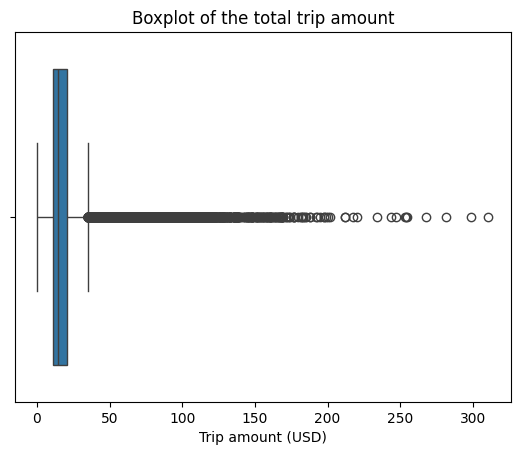

In [139]:

sns.boxplot(x=data['total_amount'])
plt.title("Boxplot of the total trip amount")
plt.xlabel("Trip amount (USD)")



In [ ]:
# analysis of most frequent time of the day and most frequent routes
# management summary with key insights dashboard-like